In [2]:
import pandas as pd
import sys
sys.path.append('/home/pulpo/Documents/quantitative-trading')

from src.quanttrading.data import prepare_data
from src.quanttrading.analysis import full_analysis

In [3]:
# DOWNLOAD DATA
df_aapl = prepare_data('AAPL', '1y','4h')
df_nvda = prepare_data('NVDA', '1y', '1d')
df_msft = prepare_data('MSFT', '1y', '1d')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


STATISTICS:
 mean:  0.069
 std:  1.089
 skew:  1.034
 kurt:  6.260

PERCENTILES:
  p05: -1.483
  p25: -0.434
  p75: 0.473
  p95: 1.708

OUTLIERS:
  Total data points: 496
  Outliers detected: 10
  Percentage: 2.02%

Plotting histogram...


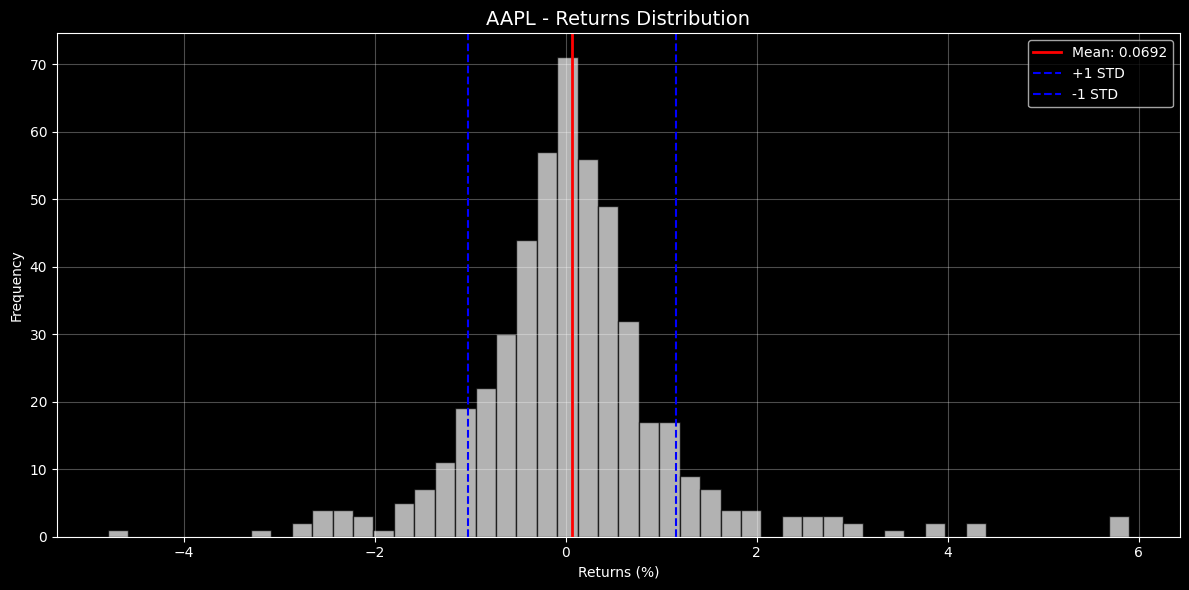

Plotting time series...


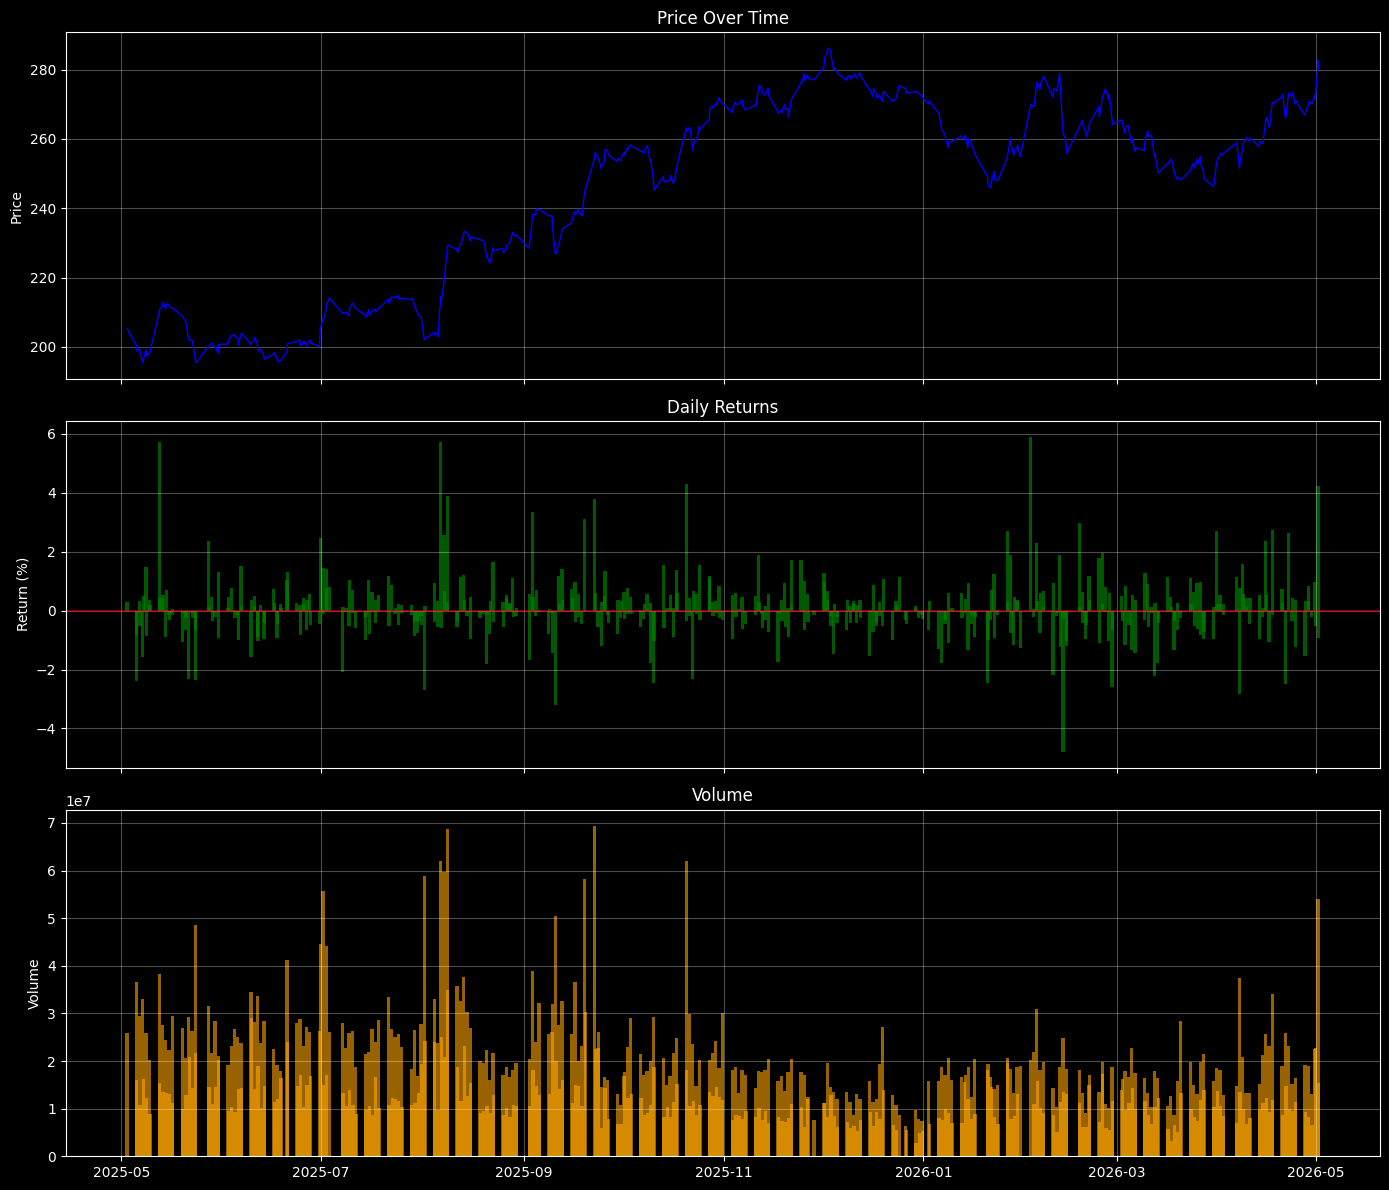

Plotting rolling statistics...


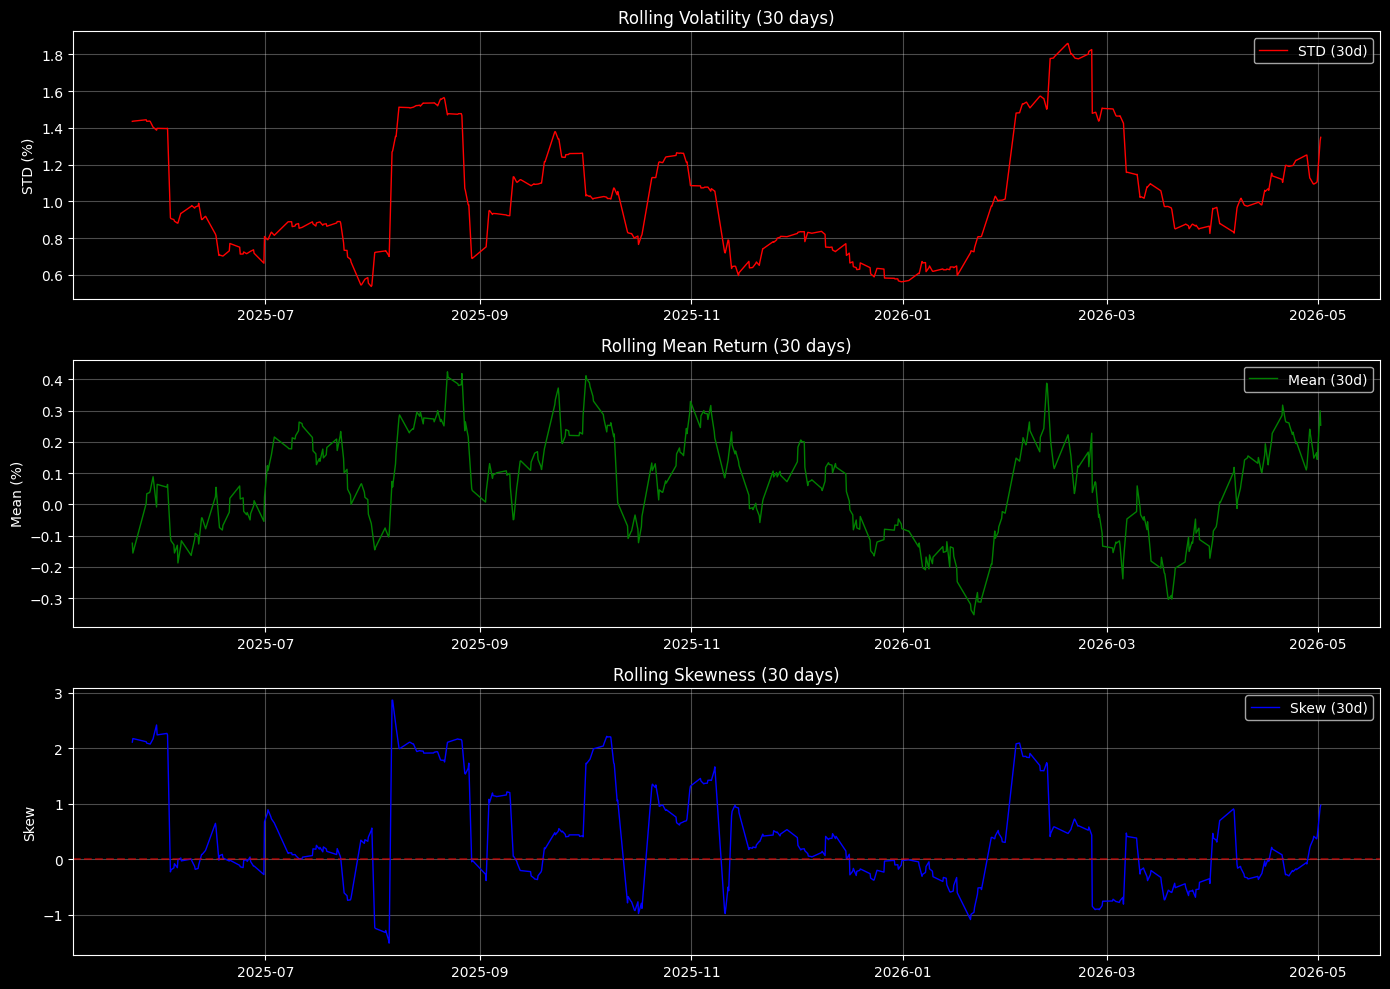

Plotting autocorrelation...


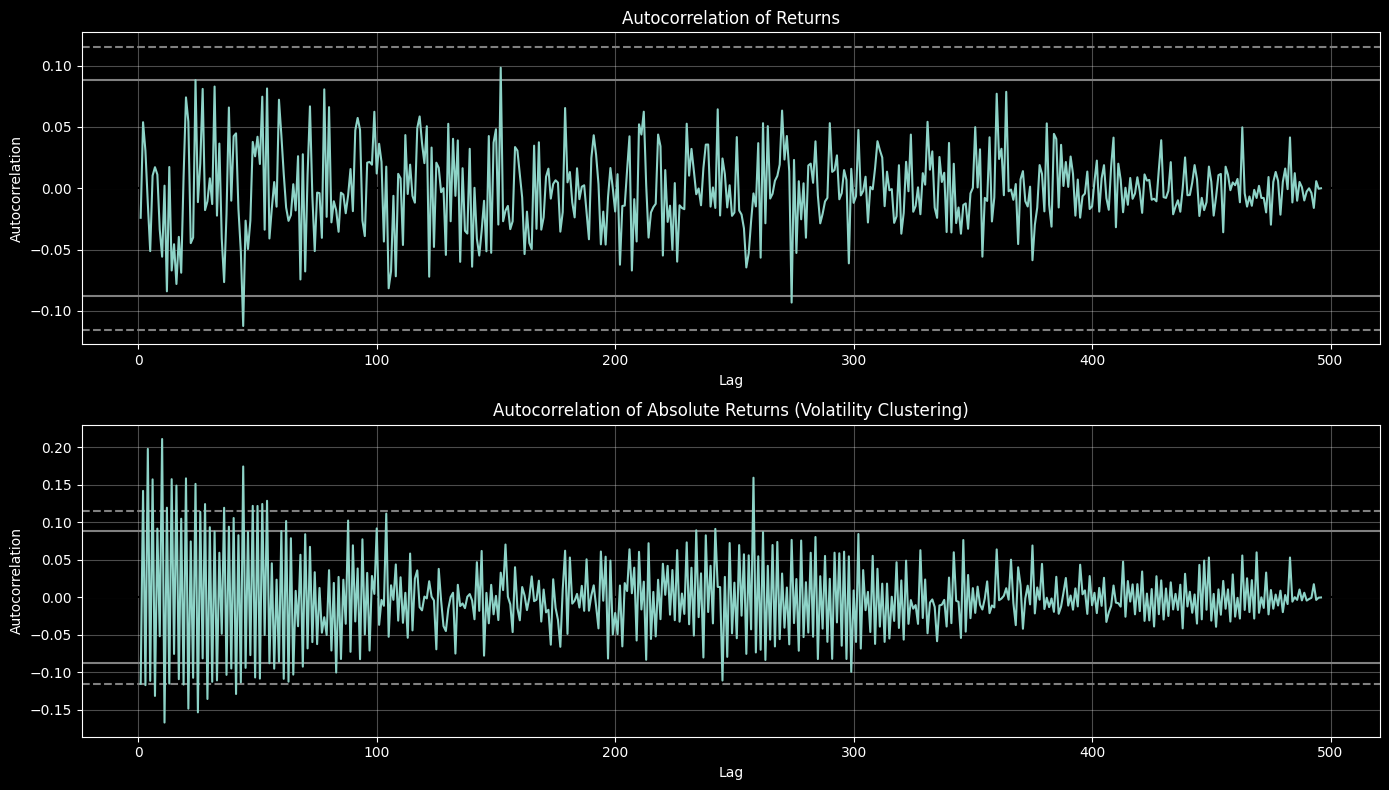


Outlier details (top 10):
Price                        Return  Distance (STD)
Datetime                                           
2025-05-12 13:30:00+00:00  5.739400        5.204616
2025-08-06 13:30:00+00:00  5.721185        5.187897
2025-08-08 13:30:00+00:00  3.881796        3.499553
2025-09-03 13:30:00+00:00  3.359537        3.020181
2025-09-10 13:30:00+00:00 -3.219549        3.018650
2025-09-22 13:30:00+00:00  3.792614        3.417694
2025-10-20 13:30:00+00:00  4.306383        3.889274
2026-02-02 18:30:00+00:00  5.899888        5.351924
2026-02-12 14:30:00+00:00 -4.794230        4.464023
2026-05-01 13:30:00+00:00  4.219492        3.809518




In [8]:
# ANALYSIS
results_aapl = full_analysis(df_aapl, 'AAPL', window=30, threshold=3)

STATISTICS:
 mean:  0.243
 std:  2.134
 skew:  0.119
 kurt:  0.529

PERCENTILES:
  p05: -3.372
  p25: -0.874
  p75: 1.576
  p95: 3.892

OUTLIERS:
  Total data points: 250
  Outliers detected: 1
  Percentage: 0.40%

Plotting histogram...


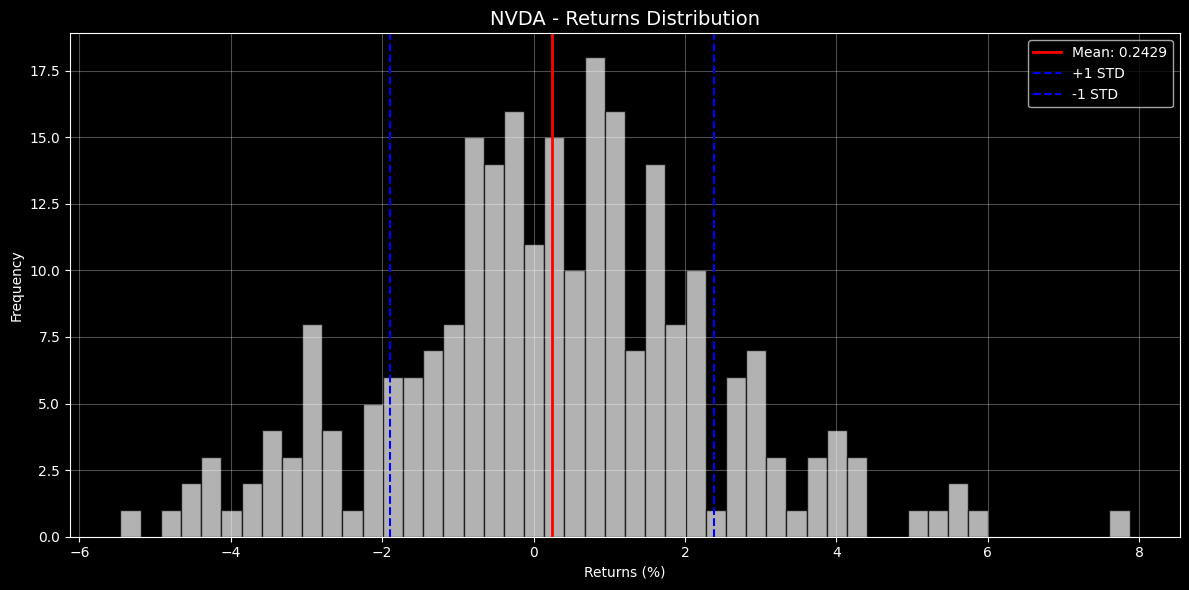

Plotting time series...


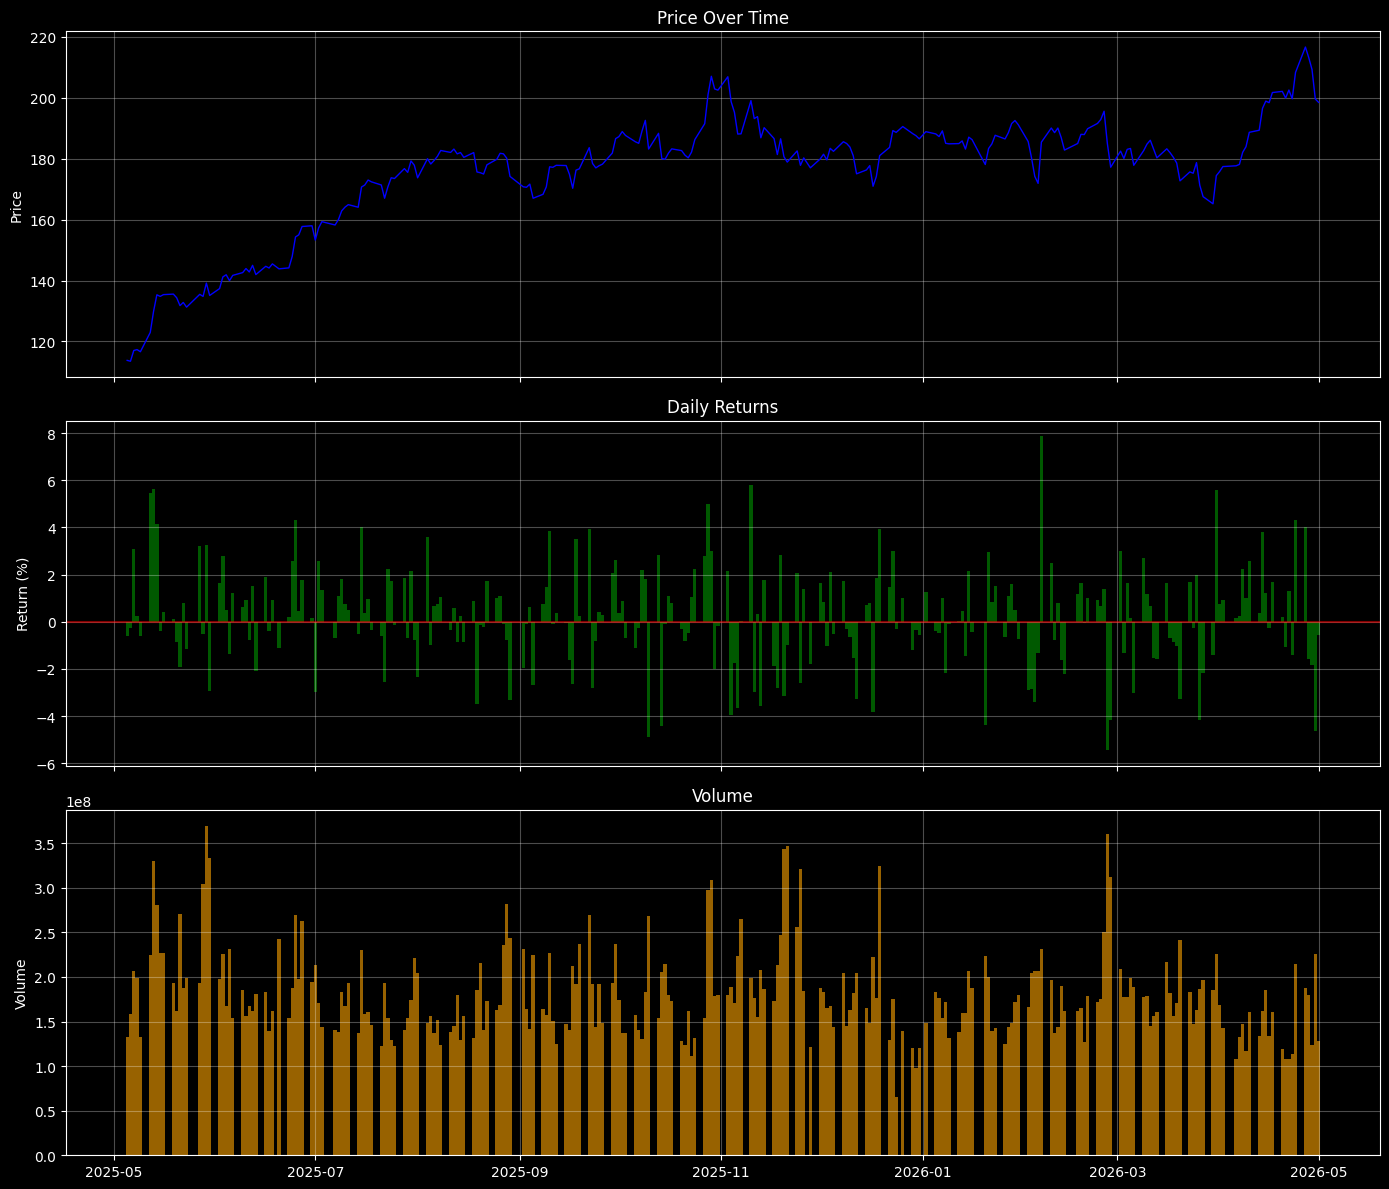

Plotting rolling statistics...


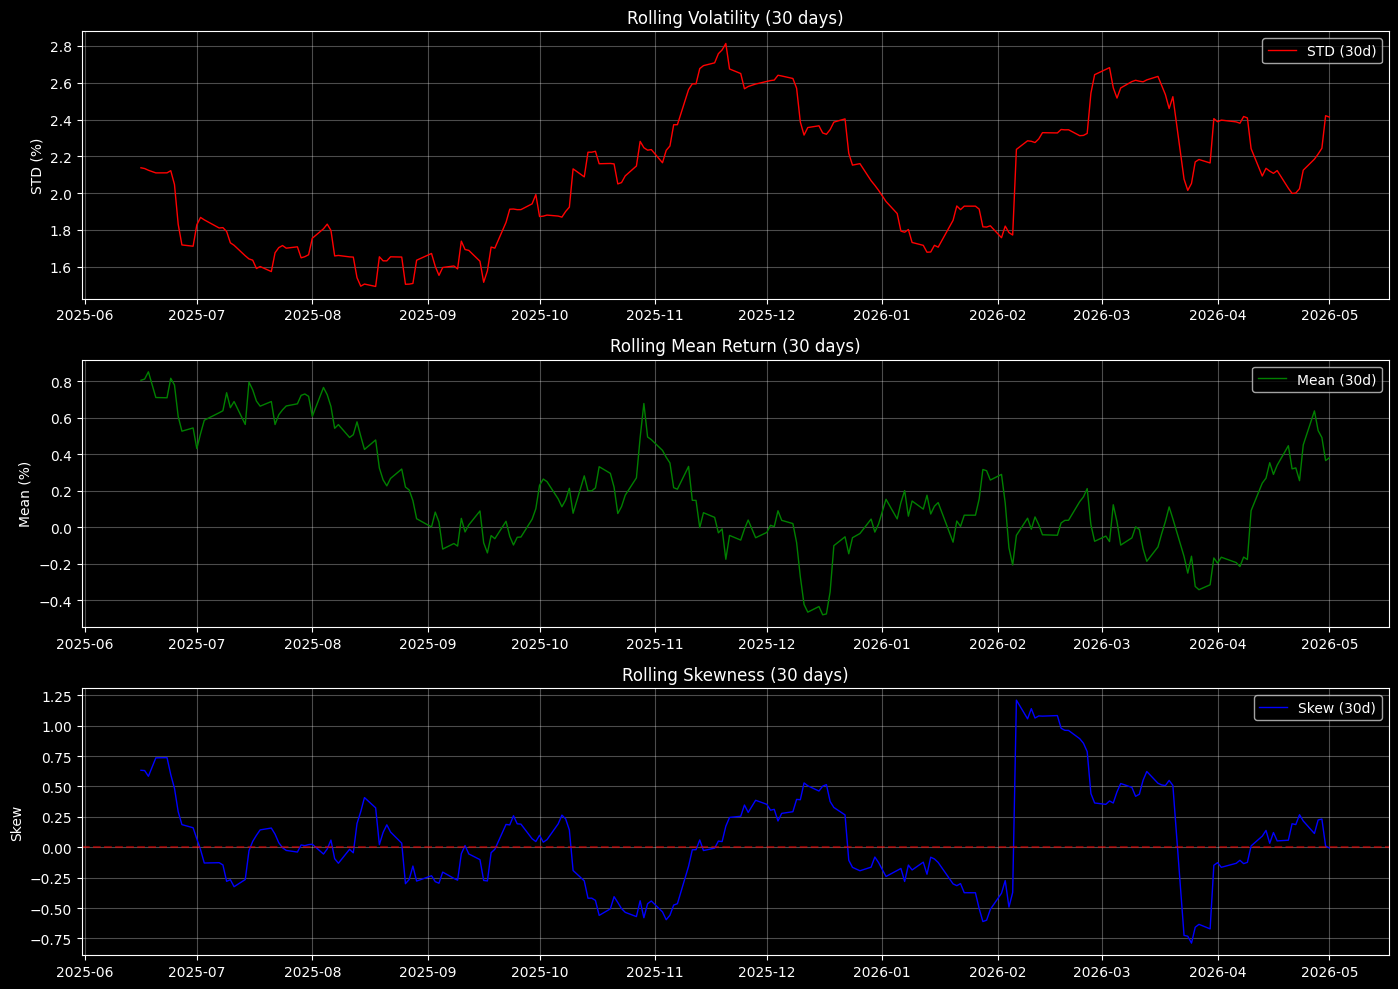

Plotting autocorrelation...


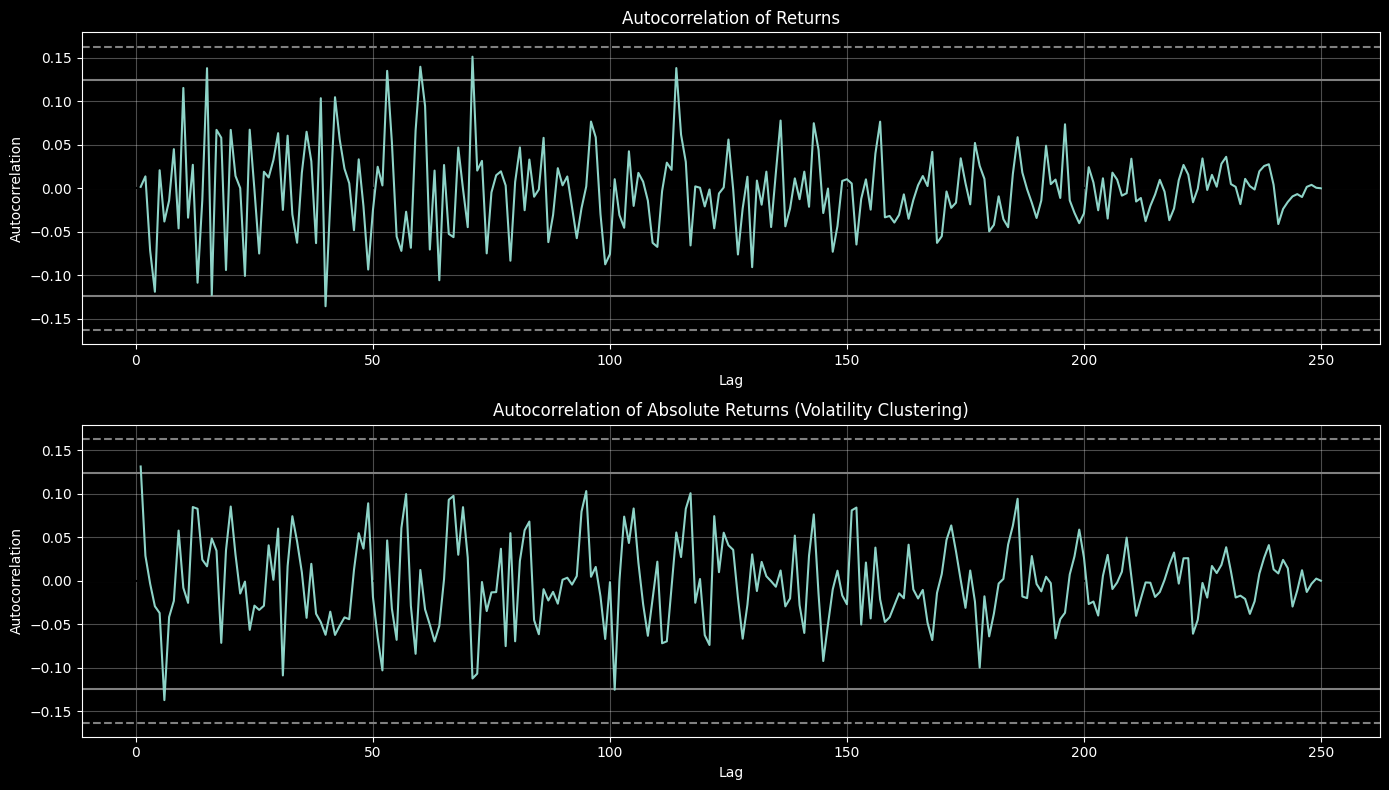


Outlier details (top 10):
Price        Return  Distance (STD)
Date                               
2026-02-06  7.87177        3.575168




In [5]:
results_nvda = full_analysis(df_nvda, 'NVDA', 30, 3)

STATISTICS:
 mean: -0.005
 std:  1.487
 skew: -1.275
 kurt:  8.331

PERCENTILES:
  p05: -2.457
  p25: -0.648
  p75: 0.651
  p95: 2.181

OUTLIERS:
  Total data points: 250
  Outliers detected: 3
  Percentage: 1.20%

Plotting histogram...


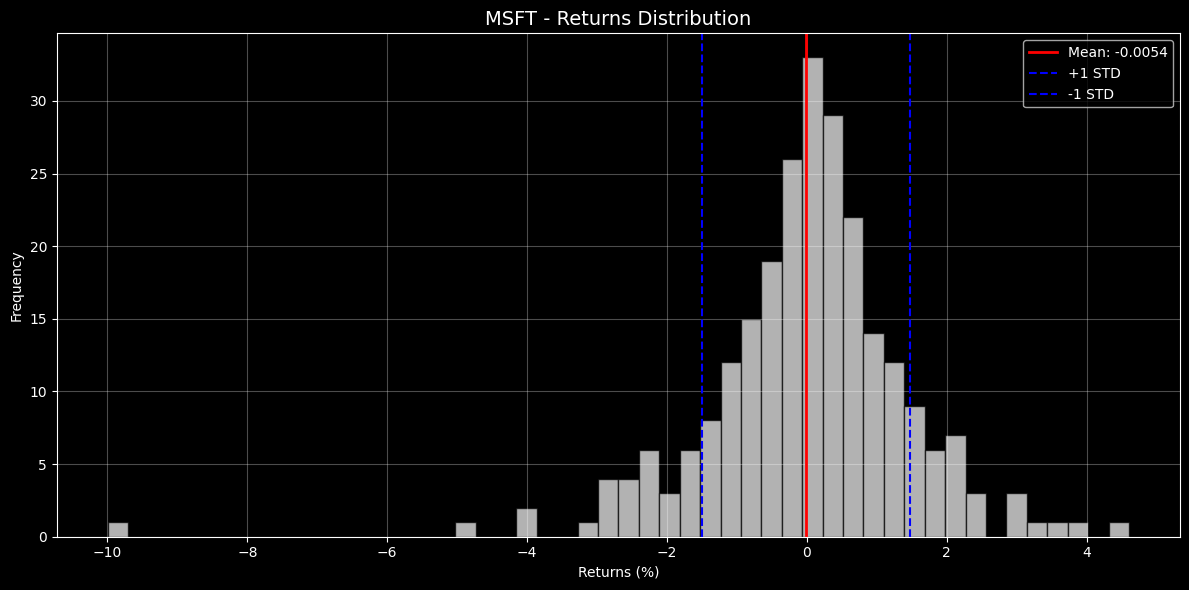

Plotting time series...


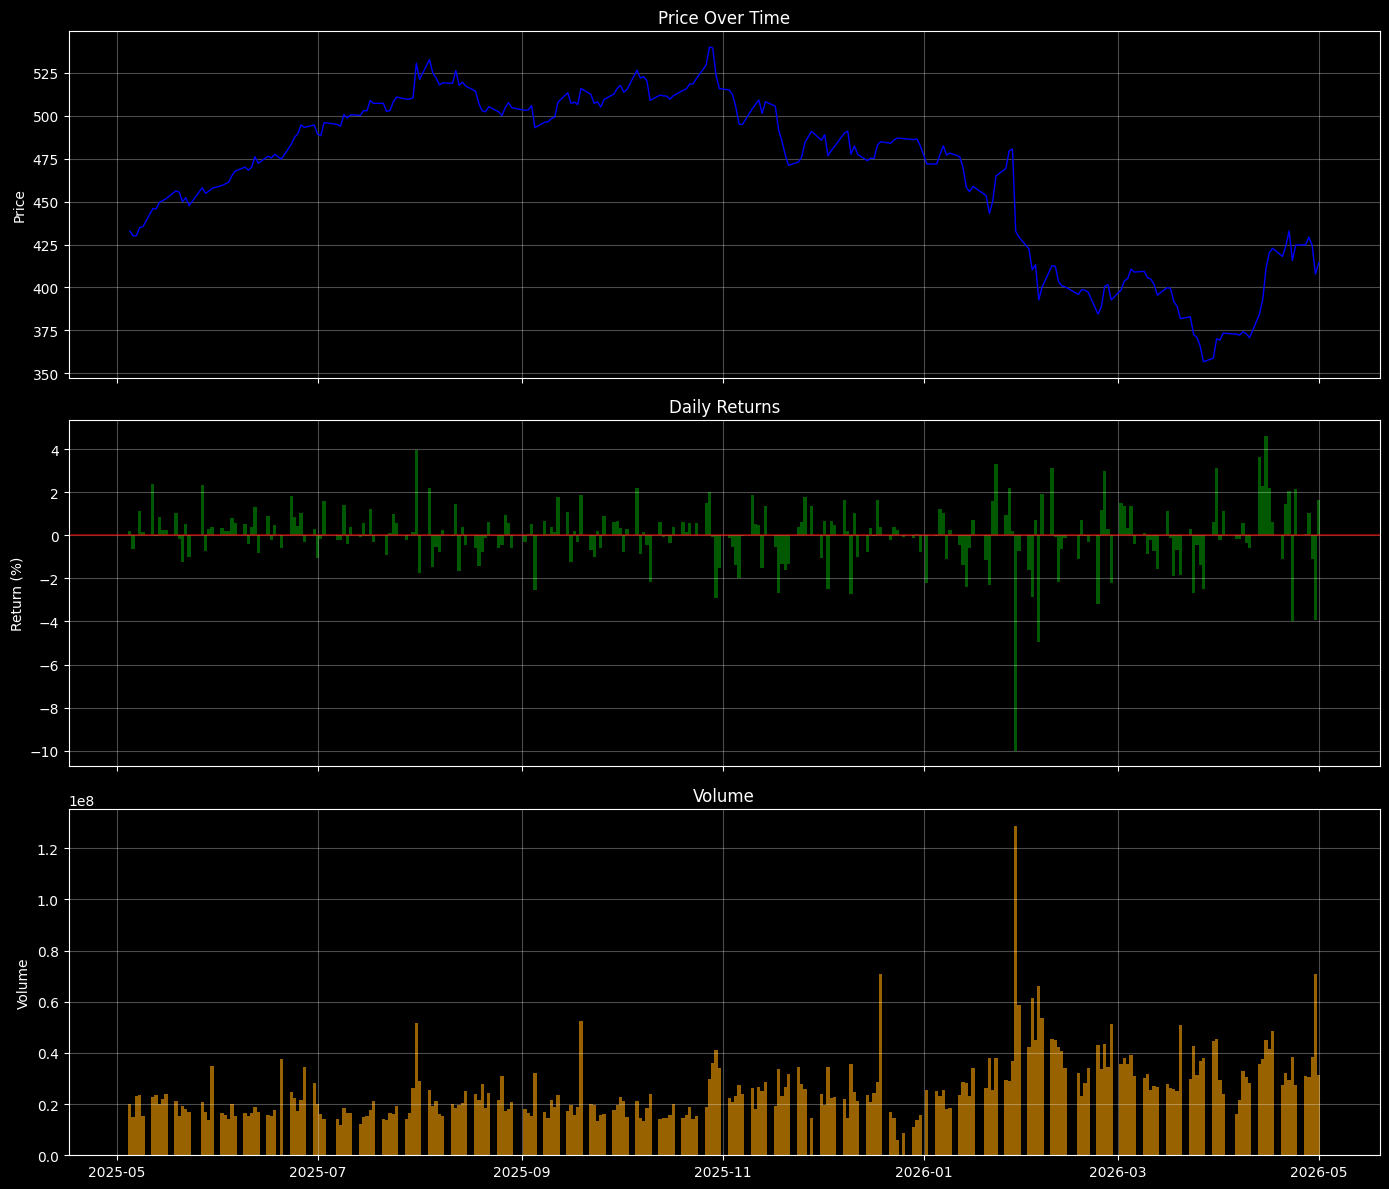

Plotting rolling statistics...


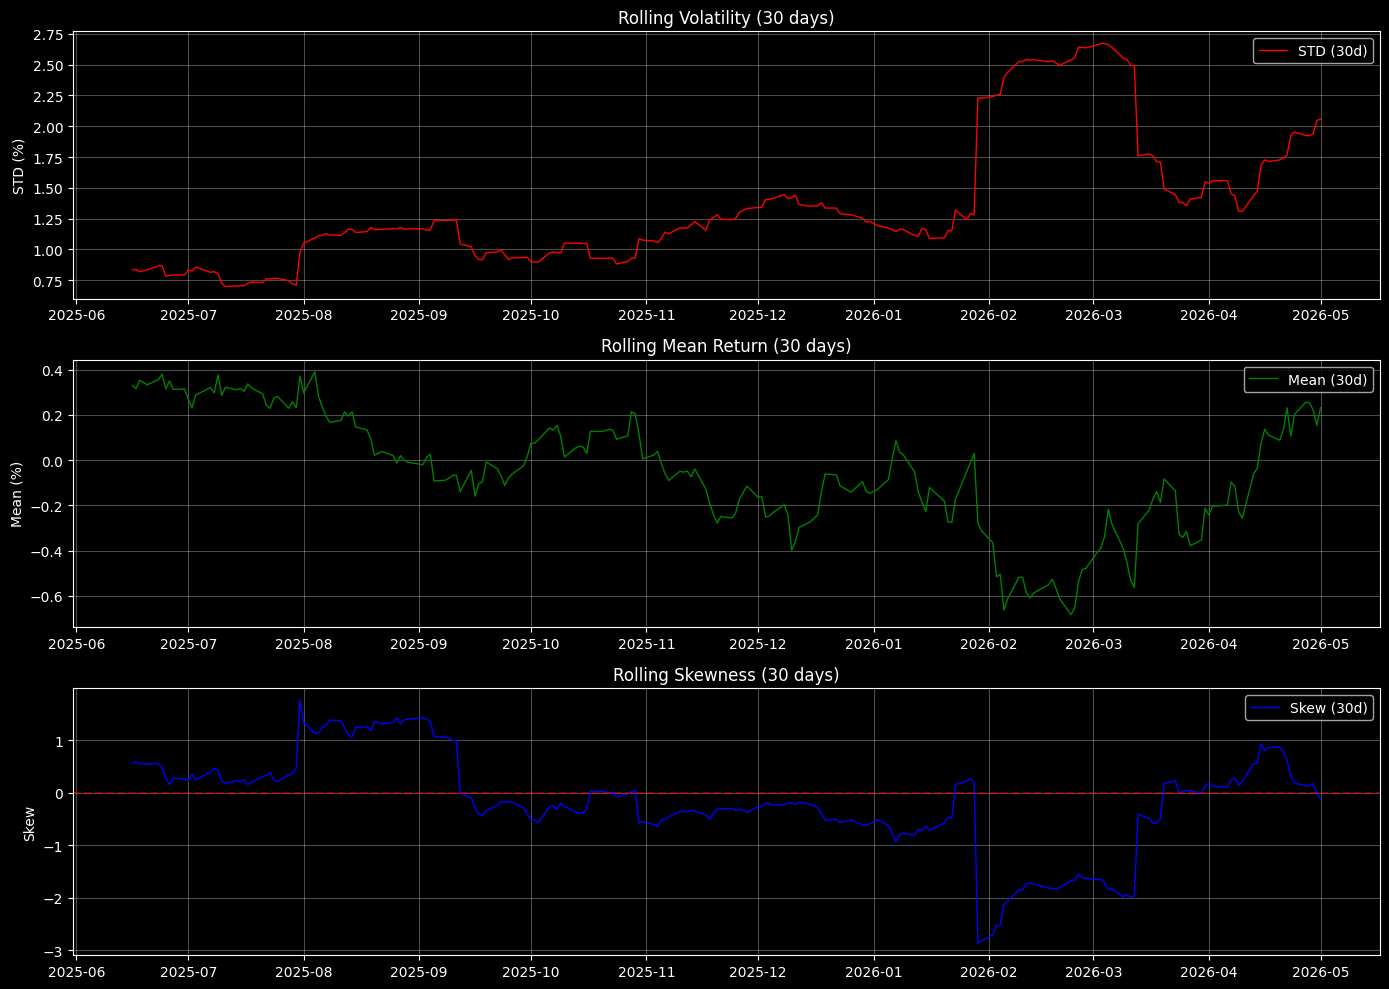

Plotting autocorrelation...


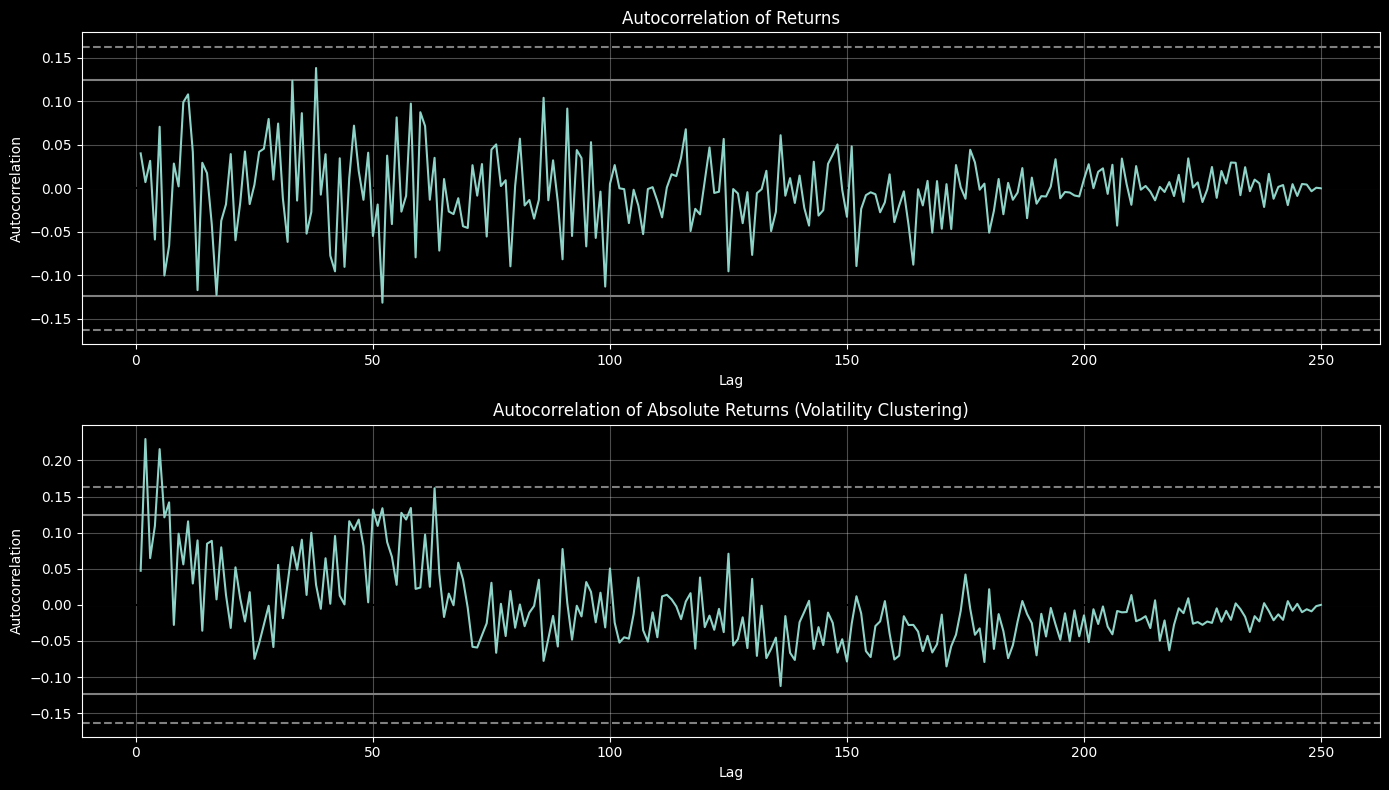


Outlier details (top 10):
Price         Return  Distance (STD)
Date                                
2026-01-29 -9.993146        6.716021
2026-02-05 -4.954247        3.327731
2026-04-15  4.606857        3.101408




In [6]:
results_msft = full_analysis(df_msft, 'MSFT', 30, 3)

In [7]:
# COMPARISON TABLE
comparison = pd.DataFrame({
    'AAPL': [results_aapl['stats']['std'], 
             results_aapl['stats']['skew'],
             results_aapl['stats']['kurt'],
             results_aapl['outlier_count']],
    'NVDA': [results_nvda['stats']['std'], 
             results_nvda['stats']['skew'],
             results_nvda['stats']['kurt'],
             results_nvda['outlier_count']],
    'MSFT': [results_msft['stats']['std'], 
             results_msft['stats']['skew'],
             results_msft['stats']['kurt'],
             results_msft['outlier_count']]
}, index=['STD', 'Skew', 'Kurtosis', 'Outliers'])

print('Comparison')
comparison.tail()

Comparison


,AAPL,NVDA,MSFT
STD,1.089464,2.133844,1.487152
Skew,1.034066,0.118750,-1.275383
Kurtosis,6.260032,0.529379,8.331171
Outliers,10.000000,1.000000,3.000000
